# Day 2 NYC School Analysis

In [59]:
import pandas as pd

In [60]:
df = pd.read_csv(r'C:\Users\Isabe\Desktop\webeet.io\Onboarding\Datasets\high-school-directory.csv')

In [61]:
import re  #imports the regular expressions module

df.columns = (
    df.columns
      .str.lower()
      .str.replace(' ', '_', regex=False)
      .str.replace(r'[^a-z0-9_]', '', regex=True)
)


In [62]:
#creates dataframe filtering on brooklyn boroughs

brooklyn_df = df[df['borough'].str.strip().str.lower() == 'brooklyn'] 

In [63]:
brooklyn_df

,dbn,school_name,borough,building_code,phone_number,fax_number,grade_span_min,grade_span_max,expgrade_span_min,expgrade_span_max,...,council_district,census_tract,bin,bbl,nta,zip_codes,community_districts,borough_boundaries,city_council_districts,police_precincts
1,21K559,Life Academy High School for Film and Music,Brooklyn,K400,718-333-7750,718-333-7775,9.0,12,NaN,NaN,...,47.0,306.0,3186454.0,3.068830e+09,Gravesend ...,17616.0,21,2,45,35
2,16K393,Frederick Douglass Academy IV Secondary School,Brooklyn,K026,718-574-2820,718-574-2821,9.0,12,NaN,NaN,...,36.0,291.0,3393805.0,3.016160e+09,Stuyvesant Heights ...,18181.0,69,2,49,52
7,17K122,Pathways in Technology Early College High Scho...,Brooklyn,K625,718-221-1593,718-221-1781,9.0,12,9.0,14.0,...,36.0,311.0,3030553.0,3.012160e+09,Crown Heights North ...,17615.0,16,2,49,49
10,23K644,Eagle Academy for Young Men II,Brooklyn,K271,718-495-0863,718-732-2129,6.0,12,NaN,NaN,...,41.0,301.0,3042157.0,3.015500e+09,Ocean Hill ...,13516.0,55,2,17,46
12,15K462,Secondary School for Law,Brooklyn,K460,718-832-4250,718-499-3947,9.0,12,NaN,NaN,...,39.0,155.0,3025510.0,3.010820e+09,Park Slope-Gowanus ...,17617.0,14,2,27,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
422,17K524,International High School at Prospect Heights,Brooklyn,K440,718-230-6333,718-230-6322,9.0,12,NaN,NaN,...,35.0,213.0,3029686.0,3.011870e+09,Crown Heights South ...,13509.0,17,2,48,44
423,17K408,Academy of Hospitality and Tourism,Brooklyn,K465,718-564-2580,718-564-2581,9.0,12,NaN,NaN,...,40.0,794.0,3336215.0,3.051030e+09,Erasmus ...,13510.0,60,2,11,43
427,15K592,Khalil Gibran International Academy,Brooklyn,K806,718-237-2502,718-488-1724,9.0,12,NaN,NaN,...,33.0,39.0,3331754.0,3.001740e+09,DUMBO-Vinegar Hill-Downtown Brooklyn-Boerum Hi...,17619.0,68,2,38,54
432,32K549,Bushwick School for Social Justice,Brooklyn,K480,718-381-7100,718-418-0192,9.0,12,NaN,NaN,...,37.0,435.0,3076908.0,3.033650e+09,Bushwick North ...,18181.0,42,2,37,53


**Question 1:** How many total schools are in Brooklyn?  
Answer: 121 schools

In [64]:
#filters on brooklyn boroughs using unique dbns

brooklyn_schools = (
    df.loc[
        df['borough'].str.strip().str.lower() == 'brooklyn',
        ['borough', 'dbn']
    ]
    .drop_duplicates()
)
brooklyn_schools


,borough,dbn
1,Brooklyn,21K559
2,Brooklyn,16K393
7,Brooklyn,17K122
10,Brooklyn,23K644
12,Brooklyn,15K462
...,...,...
422,Brooklyn,17K524
423,Brooklyn,17K408
427,Brooklyn,15K592
432,Brooklyn,32K549


In [75]:
#filters & counts unique brooklyn schools, including schools before grade 9 (also offering grade 9 with expanded grades.)

brooklyn_grade9_schools = (
    df.loc[
        (df['borough'].str.strip().str.lower() == 'brooklyn') & 
        ((df['grade_span_min'].le(9) & df['grade_span_max'].ge(9)) | (df['expgrade_span_min'].le(9) & df['expgrade_span_max'].ge(9))),
        ['borough', 'dbn','grade_span_min','expgrade_span_min']
    ]
    .drop_duplicates()
)


**Question 2:** How many schools in Brooklyn offer Grade 9 entry?  
Answer: 121 schools

In [77]:
brooklyn_grade9_schools

,borough,dbn,grade_span_min,expgrade_span_min
1,Brooklyn,21K559,9.0,NaN
2,Brooklyn,16K393,9.0,NaN
7,Brooklyn,17K122,9.0,9.0
10,Brooklyn,23K644,6.0,NaN
12,Brooklyn,15K462,9.0,NaN
...,...,...,...,...
422,Brooklyn,17K524,9.0,NaN
423,Brooklyn,17K408,9.0,NaN
427,Brooklyn,15K592,9.0,NaN
432,Brooklyn,32K549,9.0,NaN


## Overall Summary:  
  
**Count of schools per borough:** 



In [26]:
#filters & counts on unique schools using dbn

schools_per_borough = (
    df[['borough', 'dbn']]
    .drop_duplicates()
    .groupby('borough')
    .size()
    .reset_index(name='school_count')
)
schools_per_borough

,borough,school_count
0,Bronx,118
1,Brooklyn,121
2,Manhattan,106
3,Queens,80
4,Staten Island,10


**Average number of students per borough:**

In [55]:
#average number of students per borough

avg_students_per_borough = (
    df[['borough', 'dbn', 'total_students']]
    .groupby('borough')['total_students']
    .mean()
    .reset_index(name='avg_students')
)

avg_students_per_borough.round(2)


,borough,avg_students
0,Bronx,490.41
1,Brooklyn,699.13
2,Manhattan,589.83
3,Queens,1046.64
4,Staten Island,1847.50


**Summary of grade_span_max grouped by borough:**

In [49]:
#summary of grade_span_max statistics

grade_span_max_summary = (
    df.groupby('borough')['grade_span_max']
    .describe()
)

grade_span_max_summary.round(2)

,count,mean,std,min,25%,50%,75%,max
borough,,,,,,,,
Bronx,118.0,11.91,0.37,9.0,12.0,12.0,12.0,12.0
Brooklyn,121.0,11.93,0.38,9.0,12.0,12.0,12.0,12.0
Manhattan,106.0,11.88,0.47,9.0,12.0,12.0,12.0,12.0
Queens,80.0,11.82,0.50,10.0,12.0,12.0,12.0,12.0
Staten Island,10.0,12.00,0.00,12.0,12.0,12.0,12.0,12.0


<Axes: xlabel='borough'>

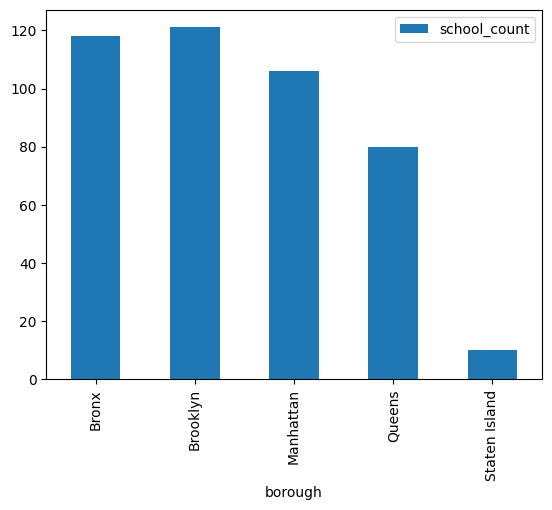

In [54]:
schools_per_borough.plot.bar(x="borough", y="school_count")

## Key Insights  
  
- Staten Island has by far the lowest amount of schools per borough, although they have the highest average number of students per school.
- Staten Island also has the highest expected grade, combined with the highest average number of students per school, most are expected to graduate.